# 📚 Knowledge Tracing with RNN (ASSISTments2017)

**Task 3 — Deep Learning for Educational Data Mining**


In [31]:
# %pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn tqdm

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


Using device: cpu


---
## 2. Data Loading



In [32]:
DATA_PATH = 'assistments2017.csv'   

df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)


Shape: (85132, 12)

Columns: ['studentId', 'skill', 'problemType', 'startTime', 'timeTaken', 'correct', 'hintCount', 'attemptCount', 'frPast5WrongCount', 'responseIsFillIn', 'responseIsChosen', 'consecutiveErrorsInRow']

First 3 rows:


,studentId,skill,problemType,startTime,timeTaken,correct,hintCount,attemptCount,frPast5WrongCount,responseIsFillIn,responseIsChosen,consecutiveErrorsInRow
0,8,perimeter,textfieldquestion,2005-05-09 13:55:03,67.0,0,1,1,0,0,0,0
1,8,perimeter,textfieldquestion,2005-05-09 13:56:10,5.0,0,2,2,0,0,0,0
2,8,perimeter,textfieldquestion,2005-05-09 13:56:15,14.0,1,2,3,0,0,0,0


In [33]:
print('=== Data Types & Missing Values ===')
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(2)
})
print(info)

print('\n=== Numeric Summary ===')
df.describe()


=== Data Types & Missing Values ===
                          dtype  missing  missing%
studentId                 int64        0       0.0
skill                    object        0       0.0
problemType              object        0       0.0
startTime                object        0       0.0
timeTaken               float64        0       0.0
correct                   int64        0       0.0
hintCount                 int64        0       0.0
attemptCount              int64        0       0.0
frPast5WrongCount         int64        0       0.0
responseIsFillIn          int64        0       0.0
responseIsChosen          int64        0       0.0
consecutiveErrorsInRow    int64        0       0.0

=== Numeric Summary ===


,studentId,timeTaken,correct,hintCount,attemptCount,frPast5WrongCount,responseIsFillIn,responseIsChosen,consecutiveErrorsInRow
count,85132.000000,85132.000000,85132.000000,85132.000000,85132.000000,85132.000000,85132.000000,85132.0,85132.000000
mean,3879.549735,43.847258,0.418820,0.993739,2.333835,0.794578,0.033865,0.0,0.170242
std,2254.263083,94.626568,0.493369,1.681901,2.216799,0.866875,0.180883,0.0,0.827626
min,8.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000
25%,1989.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000
50%,3815.000000,18.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.0,0.000000
75%,5851.000000,45.000000,1.000000,2.000000,3.000000,1.000000,0.000000,0.0,0.000000
max,7783.000000,9999.000000,1.000000,38.000000,45.000000,5.000000,1.000000,0.0,33.000000


---
## 3. Exploratory Data Analysis (EDA)


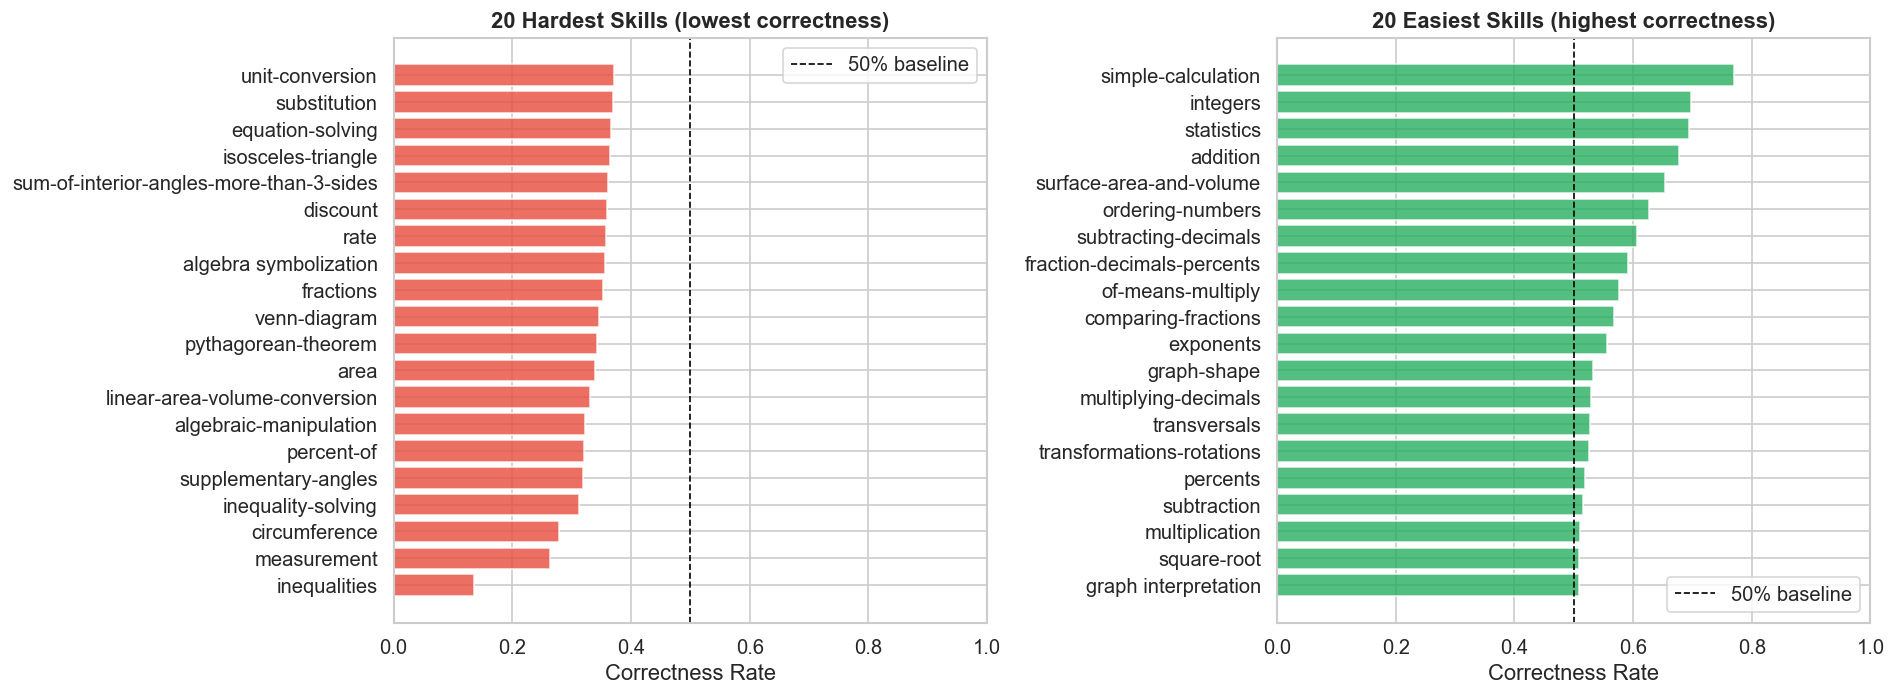

Overall correctness rate: 0.419
Class imbalance — correct=1: 41.9%  |  correct=0: 58.1%


In [34]:
# ── Correctness Rate by Skill ────────────────────────────────────────────

skill_correct = (
    df.groupby('skill')['correct']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'correctness_rate', 'count': 'n_interactions'})
      .reset_index()
)

skill_correct = skill_correct[skill_correct['n_interactions'] >= 50]
skill_correct = skill_correct.sort_values('correctness_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, subset, title, color in zip(
    axes,
    [skill_correct.head(20), skill_correct.tail(20)],
    ['20 Hardest Skills (lowest correctness)', '20 Easiest Skills (highest correctness)'],
    ['#E74C3C', '#27AE60']
):
    ax.barh(subset['skill'].astype(str), subset['correctness_rate'], color=color, alpha=0.8)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% baseline')
    ax.set_xlabel('Correctness Rate')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.legend()

plt.tight_layout()
plt.savefig('eda_skill_correctness.png', bbox_inches='tight')
plt.show()

print(f'Overall correctness rate: {df["correct"].mean():.3f}')
print(f'Class imbalance — correct=1: {df["correct"].mean()*100:.1f}%  |  correct=0: {(1-df["correct"].mean())*100:.1f}%')


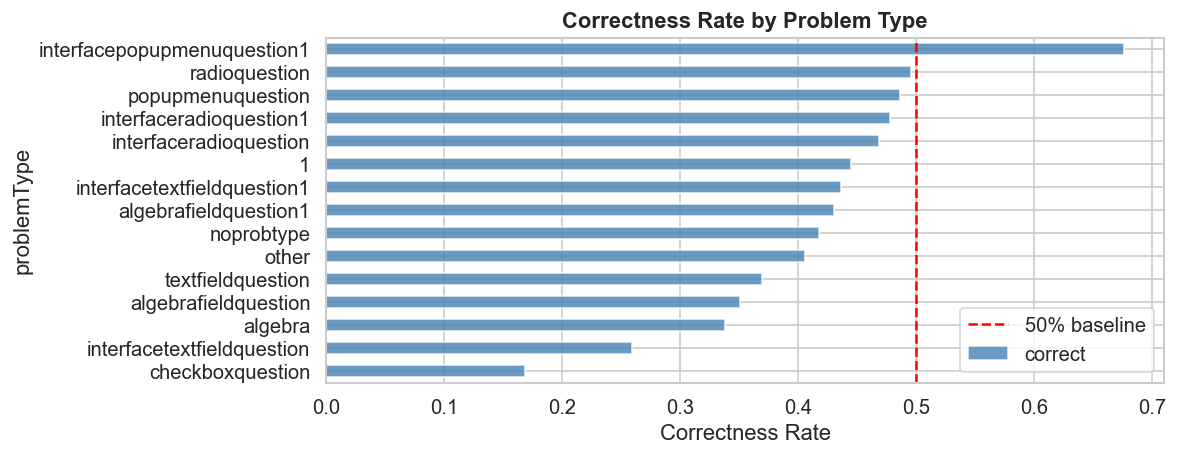

In [35]:
# ── Correctness Rate by Problem Type ─────────────────────────────────────

pt_correct = df.groupby('problemType')['correct'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
pt_correct.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', label='50% baseline')
ax.set_xlabel('Correctness Rate')
ax.set_title('Correctness Rate by Problem Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_problemtype_correctness.png', bbox_inches='tight')
plt.show()



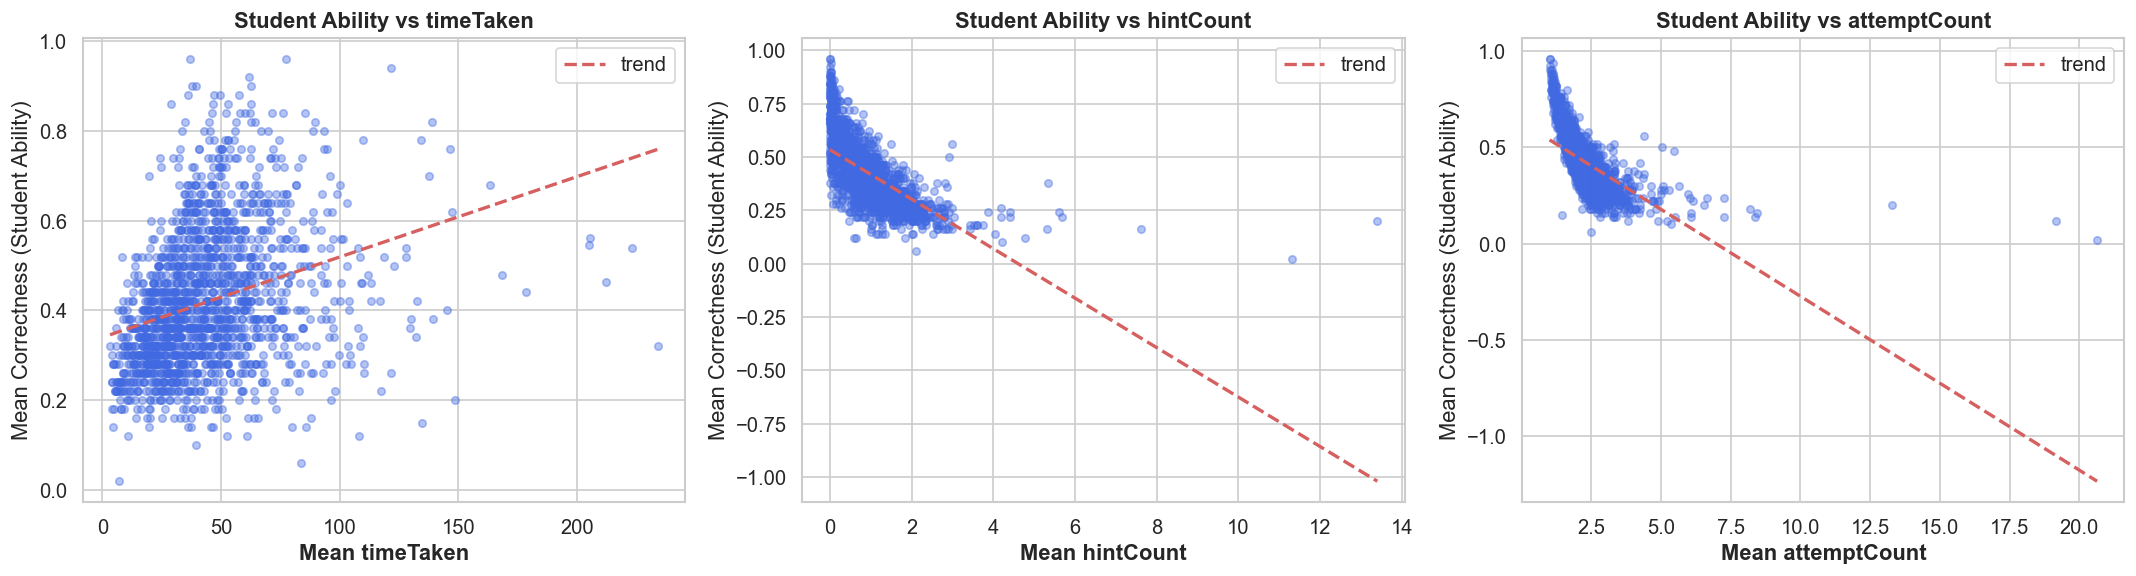

In [36]:
# ── Student Ability vs Help-Seeking Behaviour ───────────────────────────

help_cols = [c for c in ['timeTaken', 'hintCount', 'attemptCount'] if c in df.columns]

student_agg = df.groupby('studentId').agg(
    mean_correct=('correct', 'mean'),
    **{f'mean_{c}': (c, 'mean') for c in help_cols}
).reset_index()

fig, axes = plt.subplots(1, len(help_cols), figsize=(6 * len(help_cols), 5))
if len(help_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, help_cols):
    ax.scatter(
        student_agg[f'mean_{col}'], student_agg['mean_correct'],
        alpha=0.4, s=20, color='royalblue'
    )
    # Trend line
    z = np.polyfit(student_agg[f'mean_{col}'].dropna(),
                   student_agg.loc[student_agg[f'mean_{col}'].notna(), 'mean_correct'], 1)
    p = np.poly1d(z)
    xs = np.linspace(student_agg[f'mean_{col}'].min(), student_agg[f'mean_{col}'].max(), 100)
    ax.plot(xs, p(xs), 'r--', linewidth=2, label='trend')
    ax.set_xlabel(f'Mean {col}', fontweight='bold')
    ax.set_ylabel('Mean Correctness (Student Ability)')
    ax.set_title(f'Student Ability vs {col}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_ability_vs_help.png', bbox_inches='tight')
plt.show()


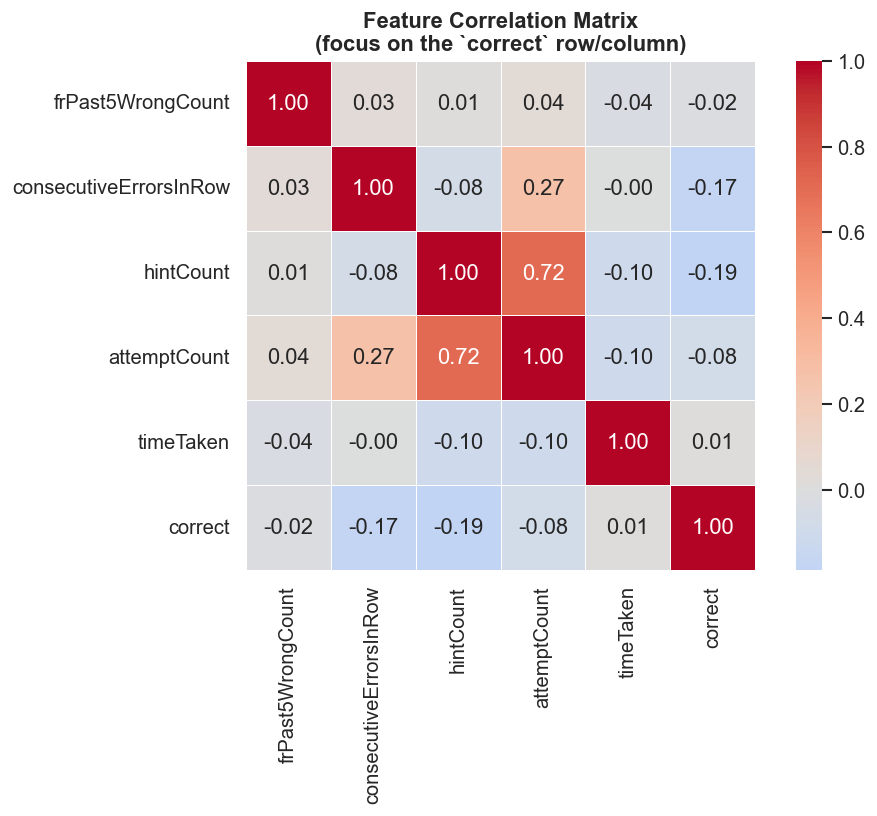


Correlation with target `correct`:
correct                   1.000000
timeTaken                 0.013690
frPast5WrongCount        -0.017019
attemptCount             -0.083611
consecutiveErrorsInRow   -0.174619
hintCount                -0.187649
Name: correct, dtype: float64


In [37]:
# ── Correlation Analysis ─────────────────────────────────────────────────

corr_cols = [c for c in [
    'frPast5WrongCount', 'consecutiveErrorsInRow',
    'hintCount', 'attemptCount', 'timeTaken',
    'frPast5RightCount', 'correct'
] if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, mask=False,
    linewidths=0.5, square=True
)
ax.set_title('Feature Correlation Matrix\n(focus on the `correct` row/column)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

print('\nCorrelation with target `correct`:')
print(corr_matrix['correct'].sort_values(ascending=False))


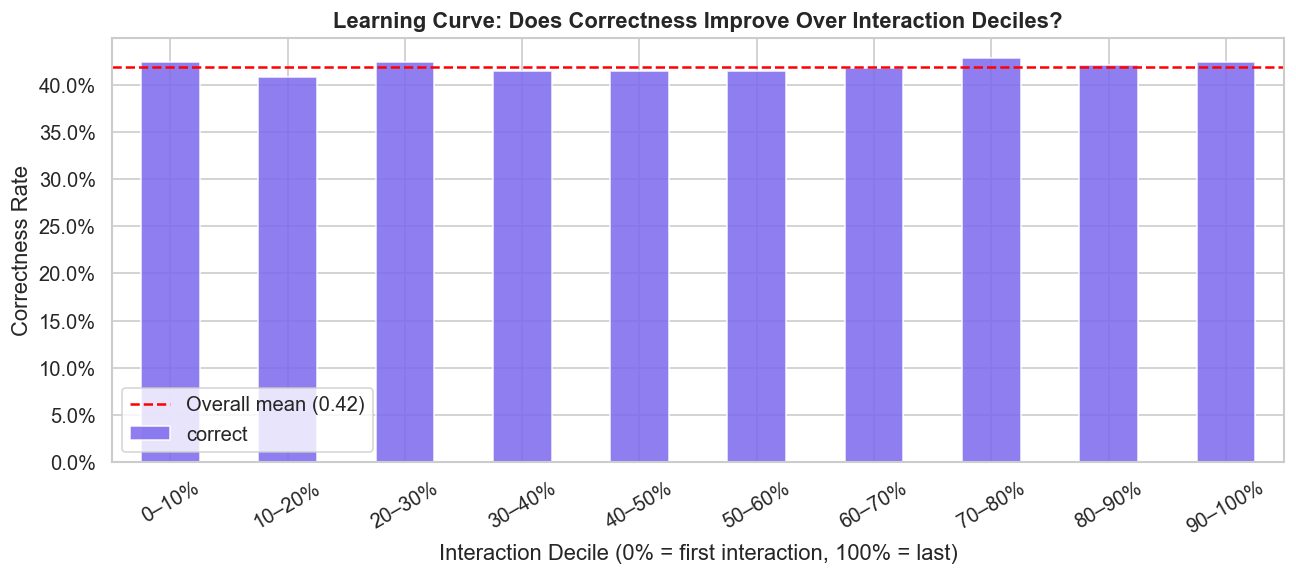

In [38]:
# ── Temporal Dynamics — Do Students Improve Over Time? ───────────────────

df_sorted = df.sort_values(['studentId', 'timestamp'] if 'timestamp' in df.columns
                           else ['studentId'])

# Compute within-student interaction rank as percentile
df_sorted['interaction_rank'] = (
    df_sorted.groupby('studentId').cumcount() /
    (df_sorted.groupby('studentId')['correct'].transform('count') - 1)
)
df_sorted['decile'] = pd.cut(
    df_sorted['interaction_rank'],
    bins=np.linspace(0, 1, 11),
    labels=[f'{i*10}–{i*10+10}%' for i in range(10)],
    include_lowest=True
)

decile_correct = df_sorted.groupby('decile', observed=True)['correct'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
decile_correct.plot(kind='bar', ax=ax, color='mediumslateblue', alpha=0.85, edgecolor='white')
ax.axhline(df['correct'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["correct"].mean():.2f})')
ax.set_xlabel('Interaction Decile (0% = first interaction, 100% = last)')
ax.set_ylabel('Correctness Rate')
ax.set_title('Learning Curve: Does Correctness Improve Over Interaction Deciles?', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('eda_learning_curve.png', bbox_inches='tight')
plt.show()


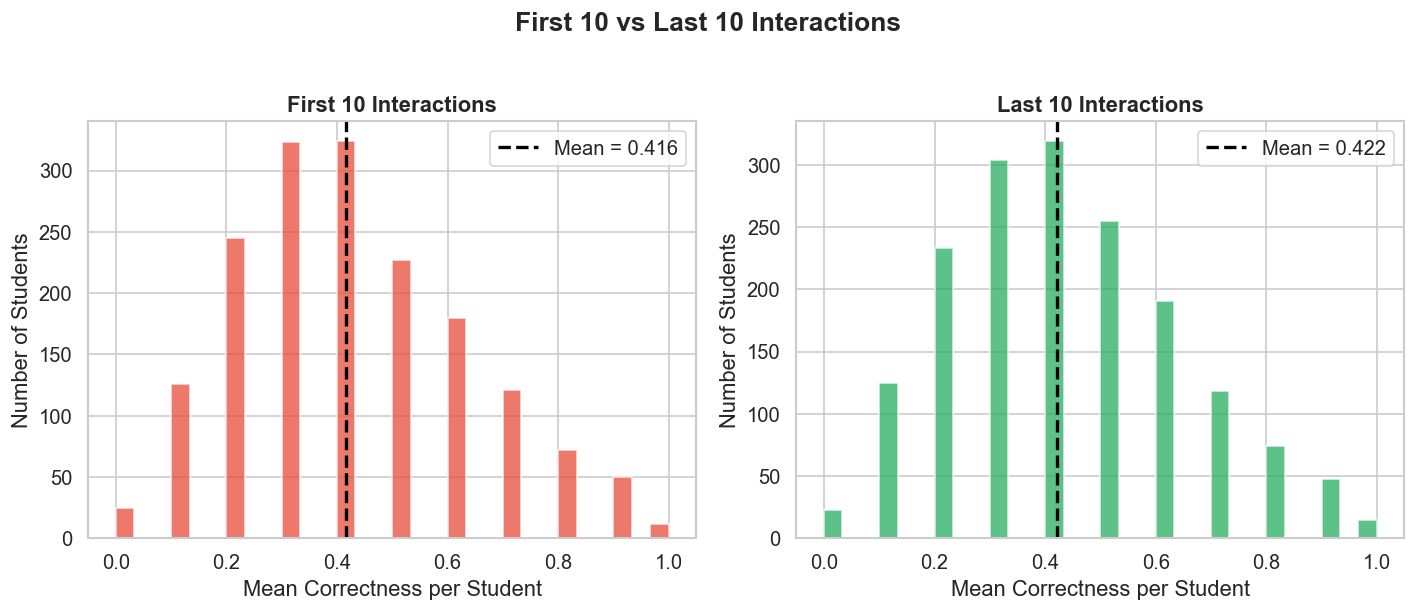

Mean correctness — First 10: 0.416  |  Last 10: 0.422
Improvement: 0.007


In [39]:
# ── 3.6  First 10 vs Last 10 Interactions ─────────────────────────────────────

def get_positional_correctness(df_s, n=10, position='first'):
    """Return mean correctness of the first or last n interactions per student."""
    results = []
    for _, grp in df_s.groupby('studentId'):
        if len(grp) >= n:
            subset = grp.head(n) if position == 'first' else grp.tail(n)
            results.append(subset['correct'].mean())
    return np.array(results)

first_10 = get_positional_correctness(df_sorted, 10, 'first')
last_10  = get_positional_correctness(df_sorted, 10, 'last')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, label, color in zip(
    axes,
    [first_10, last_10],
    ['First 10 Interactions', 'Last 10 Interactions'],
    ['#E74C3C', '#27AE60']
):
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='black', linewidth=2, linestyle='--',
               label=f'Mean = {data.mean():.3f}')
    ax.set_xlabel('Mean Correctness per Student')
    ax.set_ylabel('Number of Students')
    ax.set_title(label, fontweight='bold')
    ax.legend()

plt.suptitle('First 10 vs Last 10 Interactions',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_first_vs_last.png', bbox_inches='tight')
plt.show()

print(f'Mean correctness — First 10: {first_10.mean():.3f}  |  Last 10: {last_10.mean():.3f}')
print(f'Improvement: {last_10.mean() - first_10.mean():.3f}')


---
## 4. Preprocessing & Feature Engineering

### What we do and why:

| Step | What | Why |
|------|------|-----|
| Fill missing values | Replace NaN with 0 or median | RNNs can't handle NaN |
| Encode `skill` | Map skill names → integers | Neural nets need numbers |
| Encode `problemType` | Map problem type → integers | Same reason |
| Log-transform skewed features | `log1p(timeTaken)`, `log1p(hintCount)` | Prevents one large value dominating |
| Standardize numeric features | Z-score scaling | Stable gradient flow |
| Build sequences (sliding window) | Group by student, slide a window of size L | RNN needs fixed-length sequences |
| Pad sequences | Pre-pad short sequences with 0 | Uniform tensor shape per batch |
| Split train/val/test at sequence level | 70/15/15 | Prevent data leakage |


In [40]:
SEQ_LEN    = 10   
BATCH_SIZE = 32   
EMBED_DIM  = 32   
HIDDEN_DIM = 96   
N_LAYERS   = 2    
DROPOUT    = 0.5  
LR         = 5e-4 
N_EPOCHS   = 30   

In [41]:
# ── Fill Missing Values ──────────────────────────────────────────────────
df['hintCount']    = df['hintCount'].fillna(0)    if 'hintCount'    in df.columns else 0
df['attemptCount'] = df['attemptCount'].fillna(1) if 'attemptCount' in df.columns else 1
df['timeTaken']    = df['timeTaken'].fillna(df['timeTaken'].median()) if 'timeTaken' in df.columns else 0

for col in ['frPast5WrongCount', 'frPast5RightCount', 'consecutiveErrorsInRow']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print('Missing values filled.')
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values filled.
Series([], dtype: int64)


In [42]:
# ──  Encode Categorical Features ─────────────────────────────────────────

le_skill = LabelEncoder()
df['skill_id'] = le_skill.fit_transform(df['skill'].astype(str)) + 1  # +1 reserves 0 for padding
N_SKILLS = df['skill_id'].max() + 1   # vocabulary size (including pad token 0)
print(f'Number of unique skills (vocab size): {N_SKILLS}')

if 'problemType' in df.columns:
    le_pt = LabelEncoder()
    df['problemType_id'] = le_pt.fit_transform(df['problemType'].astype(str)) + 1
    N_PROBLEM_TYPES = df['problemType_id'].max() + 1
    print(f'Number of problem types: {N_PROBLEM_TYPES}')
else:
    df['problemType_id'] = 0
    N_PROBLEM_TYPES = 1


Number of unique skills (vocab size): 92
Number of problem types: 16


In [43]:
# ── Feature Scaling ───────────────────────────────────────────────────────

skewed_cols = [c for c in ['timeTaken', 'hintCount', 'attemptCount'] if c in df.columns]
for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])   

numeric_cols = [c for c in [
    'timeTaken_log', 'hintCount_log', 'attemptCount_log',
    'frPast5WrongCount', 'frPast5RightCount', 'consecutiveErrorsInRow'
] if c in df.columns]



In [44]:
# ── Build Sliding Window Sequences ──────────────────────────────────────

FEATURE_COLS = ['correct', 'skill_id', 'problemType_id'] + numeric_cols
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print('Feature columns:', FEATURE_COLS)

all_sequences = []

for student_id, group in tqdm(df.groupby('studentId'), desc='Building sequences'):
    feats = group[FEATURE_COLS].values.astype(np.float32)  
    T = len(feats)
    if T < SEQ_LEN + 1:  
        continue
    for start in range(T - SEQ_LEN):
        end = start + SEQ_LEN
        X = feats[start:end]                              
        y = feats[end, FEATURE_COLS.index('correct')]    
        all_sequences.append((X, float(y)))

print(f'Total sequences built: {len(all_sequences):,}')
print(f'Example shape: X={all_sequences[0][0].shape}, y={all_sequences[0][1]}')

# Show label balance
labels = [s[1] for s in all_sequences]
print(f'Label balance — correct=1: {sum(labels)/len(labels)*100:.1f}%')


Feature columns: ['correct', 'skill_id', 'problemType_id', 'timeTaken_log', 'hintCount_log', 'attemptCount_log', 'frPast5WrongCount', 'consecutiveErrorsInRow']


Building sequences: 100%|██████████| 1705/1705 [00:01<00:00, 1400.30it/s]

Total sequences built: 68,082
Example shape: X=(10, 8), y=1.0
Label balance — correct=1: 42.1%


In [45]:
# ── Train / Val / Test Split — AT SEQUENCE LEVEL ─────────────────────────

random.shuffle(all_sequences)  

n = len(all_sequences)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_seqs = all_sequences[:n_train]
val_seqs   = all_sequences[n_train : n_train + n_val]
test_seqs  = all_sequences[n_train + n_val :]

print(f'Train: {len(train_seqs):,}  |  Val: {len(val_seqs):,}  |  Test: {len(test_seqs):,}')


Train: 47,657  |  Val: 10,212  |  Test: 10,213


In [46]:
# ── Scaling After Split — Prevent Data Leakage ──────────────────────────


NUMERIC_START_IDX = len(['correct', 'skill_id', 'problemType_id'])

train_numeric = np.vstack([s[0][:, NUMERIC_START_IDX:] for s in train_seqs])
scaler = StandardScaler()
scaler.fit(train_numeric)
print(f'Scaler fitted on train only — mean shape: {scaler.mean_.shape}')

def scale_sequences(seqs, scaler, numeric_start_idx=3):
    scaled = []
    for X, y in seqs:
        X_copy = X.copy()
        X_copy[:, numeric_start_idx:] = scaler.transform(X[:, numeric_start_idx:])
        scaled.append((X_copy, y))
    return scaled

train_seqs = scale_sequences(train_seqs, scaler, NUMERIC_START_IDX)
val_seqs   = scale_sequences(val_seqs,   scaler, NUMERIC_START_IDX)
test_seqs  = scale_sequences(test_seqs,  scaler, NUMERIC_START_IDX)


Scaler fitted on train only — mean shape: (5,)


---
## 5. Dataset & DataLoader

PyTorch requires data to be wrapped in a `Dataset` object, then passed through
a `DataLoader` which handles batching and shuffling for us.

**Custom collate function:** Because sequences have different lengths (short student
histories may be shorter than `SEQ_LEN`), we pad them to the same length within
each batch using pre-padding (zeros at the beginning).


In [ ]:
class KTDataset(Dataset):
    """
    PyTorch Dataset for Knowledge Tracing sequences.
    
    """
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        X, y = self.sequences[idx]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def collate_fn(batch):
    Xs, ys = zip(*batch)
    Xs_padded = pad_sequence(Xs, batch_first=True, padding_value=0.0)
    ys_tensor = torch.stack(ys)
    return Xs_padded, ys_tensor


train_dataset = KTDataset(train_seqs)
val_dataset   = KTDataset(val_seqs)
test_dataset  = KTDataset(test_seqs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

X_batch, y_batch = next(iter(train_loader))
print(f'Batch X shape: {X_batch.shape}  (batch_size × seq_len × n_features)')
print(f'Batch y shape: {y_batch.shape}')
print(f'n_features = {X_batch.shape[2]}')

N_FEATURES = X_batch.shape[2]   


Batch X shape: torch.Size([32, 10, 8])  (batch_size × seq_len × n_features)
Batch y shape: torch.Size([32])
n_features = 8


---
## 6. RNN Model Definition



In [48]:
class KnowledgeTracingRNN(nn.Module):
    """
    RNN-based Knowledge Tracing model.
    """
    def __init__(self, n_skills, embed_dim, n_features, hidden_dim, n_layers, dropout):
        super().__init__()

        self.skill_embed = nn.Embedding(
            num_embeddings=n_skills,
            embedding_dim=embed_dim,
            padding_idx=0         
        )

        rnn_input_dim = embed_dim + (n_features - 1) 

        self.rnn = nn.RNN(
            input_size=rnn_input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0, 
            nonlinearity='tanh'  
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        skill_idx = x[:, :, 1].long()              

        skill_embedded = self.skill_embed(skill_idx)      

        other_feats = torch.cat([x[:, :, :1], x[:, :, 2:]], dim=2)  
        rnn_input = torch.cat([skill_embedded, other_feats], dim=2)  


        out, h_n = self.rnn(rnn_input)

        last_hidden = h_n[-1]   

        last_hidden = self.dropout(last_hidden)

        logit = self.fc(last_hidden).squeeze(-1) 
        return torch.sigmoid(logit)


model = KnowledgeTracingRNN(
    n_skills=N_SKILLS,
    embed_dim=EMBED_DIM,
    n_features=N_FEATURES,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {n_params:,}')


KnowledgeTracingRNN(
  (skill_embed): Embedding(92, 32, padding_idx=0)
  (rnn): RNN(39, 96, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=96, out_features=1, bias=True)
)

Total trainable parameters: 34,817


---
## 7. Training

### Loss Function: Binary Cross-Entropy
Since we predict a probability ∈ [0,1] and the label is 0 or 1:
$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$



In [49]:
criterion = nn.BCELoss()           
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()         
        preds = model(X)               
        loss  = criterion(preds, y)    
        loss.backward()                
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()              
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()  
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X)
        loss  = criterion(preds, y)
        total_loss += loss.item() * len(y)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    preds_np  = np.concatenate(all_preds)
    labels_np = np.concatenate(all_labels)

    avg_loss  = total_loss / len(loader.dataset)
    accuracy  = accuracy_score(labels_np, preds_np > 0.5)
    auc       = roc_auc_score(labels_np, preds_np)

    return avg_loss, accuracy, auc, preds_np, labels_np


In [50]:
# ── Training Loop with Early Stopping ────────────────────────────────────────

PATIENCE = 7   

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_val_auc   = 0.0
best_epoch     = 0
no_improve     = 0

for epoch in range(1, N_EPOCHS + 1):
    train_loss                          = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_auc, _, _    = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    improved = val_auc > best_val_auc
    if improved:
        best_val_auc = val_auc
        best_epoch   = epoch
        no_improve   = 0
        torch.save(model.state_dict(), 'best_rnn_model.pt')
    else:
        no_improve += 1

    tag = "  ← best" if improved else f"  (no improve {no_improve}/{PATIENCE})"
    print(f'Epoch {epoch:02d}/{N_EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  '
          f'Val Loss: {val_loss:.4f}  '
          f'Val Acc: {val_acc:.4f}  '
          f'Val AUC: {val_auc:.4f}{tag}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

print(f'Best RNN at epoch {best_epoch} — Val AUC = {best_val_auc:.4f}')


Epoch 01/30  Train Loss: 0.6669  Val Loss: 0.6554  Val Acc: 0.6244  Val AUC: 0.6289  ← best
Epoch 02/30  Train Loss: 0.6551  Val Loss: 0.6488  Val Acc: 0.6361  Val AUC: 0.6391  ← best
Epoch 03/30  Train Loss: 0.6515  Val Loss: 0.6475  Val Acc: 0.6326  Val AUC: 0.6423  ← best
Epoch 04/30  Train Loss: 0.6489  Val Loss: 0.6430  Val Acc: 0.6419  Val AUC: 0.6531  ← best
Epoch 05/30  Train Loss: 0.6466  Val Loss: 0.6446  Val Acc: 0.6404  Val AUC: 0.6556  ← best
Epoch 06/30  Train Loss: 0.6431  Val Loss: 0.6416  Val Acc: 0.6369  Val AUC: 0.6581  ← best
Epoch 07/30  Train Loss: 0.6419  Val Loss: 0.6393  Val Acc: 0.6391  Val AUC: 0.6590  ← best
Epoch 08/30  Train Loss: 0.6386  Val Loss: 0.6431  Val Acc: 0.6391  Val AUC: 0.6636  ← best
Epoch 09/30  Train Loss: 0.6384  Val Loss: 0.6377  Val Acc: 0.6429  Val AUC: 0.6636  ← best
Epoch 10/30  Train Loss: 0.6350  Val Loss: 0.6357  Val Acc: 0.6391  Val AUC: 0.6688  ← best
Epoch 11/30  Train Loss: 0.6326  Val Loss: 0.6365  Val Acc: 0.6399  Val AUC: 0.6

---
## 8. Evaluation & Visualization


| Metric | What it means | Why useful for KT |
|--------|--------------|-------------------|
| **Accuracy** | % of predictions that are correct | Quick sanity check |
| **Precision** | Of predicted-correct, how many were actually correct | Avoids false alarms |
| **Recall** | Of actual-correct, how many did we catch | Avoids missing strugglers |
| **AUC** | Area under ROC curve — threshold-independent | **Best metric here** — robust to class imbalance |


In [51]:
# ── Load best model & evaluate on test set ────────────────────────────────────
model.load_state_dict(torch.load('best_rnn_model.pt', map_location=DEVICE))

test_loss, test_acc, test_auc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

test_preds_binary = (test_preds > 0.5).astype(int)

precision = precision_score(test_labels, test_preds_binary)
recall    = recall_score(test_labels, test_preds_binary)

print('=' * 50)
print('         TEST SET RESULTS — RNN MODEL')
print('=' * 50)
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  AUC       : {test_auc:.4f}')
print('=' * 50)
print()
print(classification_report(test_labels, test_preds_binary, target_names=['Incorrect (0)', 'Correct (1)']))


         TEST SET RESULTS — RNN MODEL
  Loss      : 0.6356
  Accuracy  : 0.6434  (64.34%)
  Precision : 0.6001
  Recall    : 0.4440
  AUC       : 0.6731

               precision    recall  f1-score   support

Incorrect (0)       0.66      0.79      0.72      5938
  Correct (1)       0.60      0.44      0.51      4275

     accuracy                           0.64     10213
    macro avg       0.63      0.62      0.61     10213
 weighted avg       0.64      0.64      0.63     10213



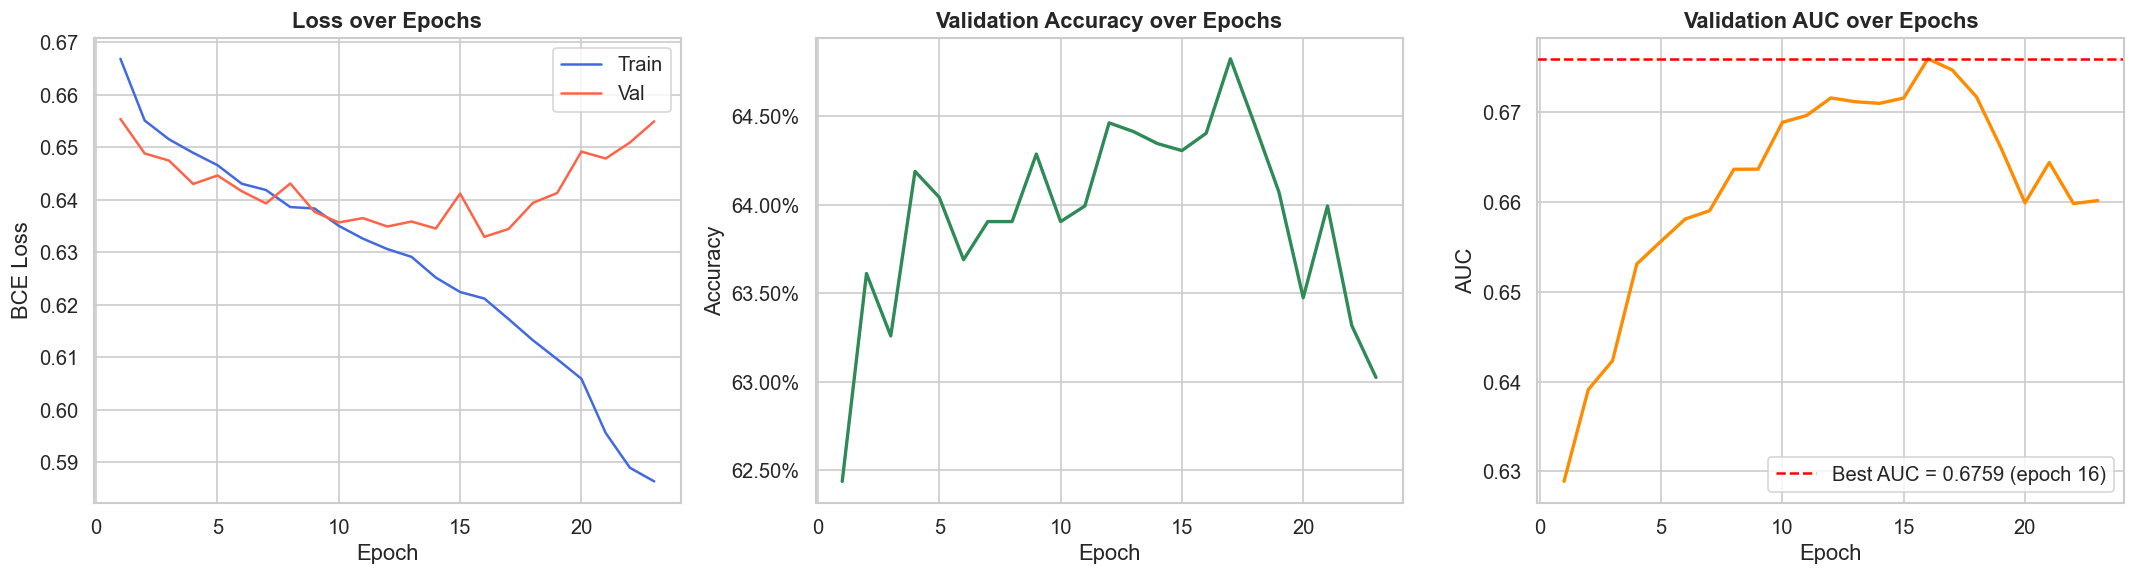

In [52]:
# ──  Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='royalblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(epochs, history['val_acc'], color='seagreen', linewidth=2)
axes[1].set_title('Validation Accuracy over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[2].plot(epochs, history['val_auc'], color='darkorange', linewidth=2)
axes[2].axhline(best_val_auc, color='red', linestyle='--',
                label=f'Best AUC = {best_val_auc:.4f} (epoch {best_epoch})')
axes[2].set_title('Validation AUC over Epochs', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves_rnn.png', bbox_inches='tight')
plt.show()


True Negatives  (correctly predicted wrong): 4673
False Positives (predicted correct, was wrong): 1265
False Negatives (predicted wrong, was correct): 2377
True Positives  (correctly predicted right): 1898


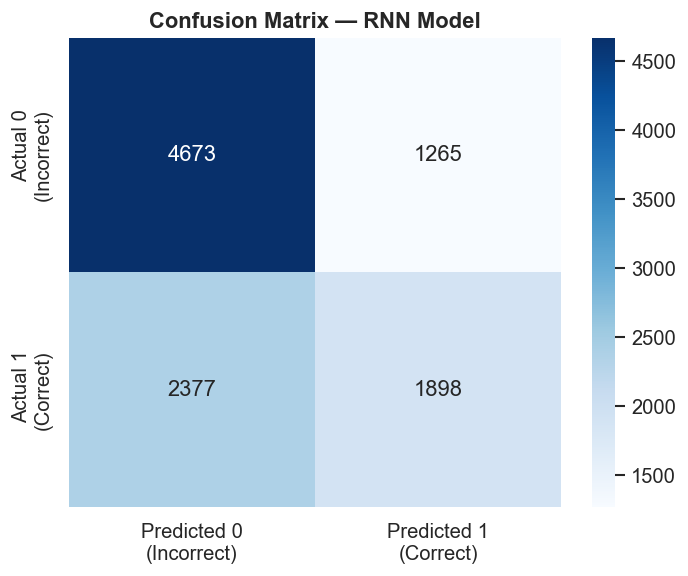

In [53]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds_binary)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predicted 0\n(Incorrect)', 'Predicted 1\n(Correct)'],
    yticklabels=['Actual 0\n(Incorrect)', 'Actual 1\n(Correct)']
)
ax.set_title('Confusion Matrix — RNN Model', fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted wrong): {tn}')
print(f'False Positives (predicted correct, was wrong): {fp}')
print(f'False Negatives (predicted wrong, was correct): {fn}')
print(f'True Positives  (correctly predicted right): {tp}')

plt.tight_layout()
plt.savefig('confusion_matrix_rnn.png', bbox_inches='tight')
plt.show()


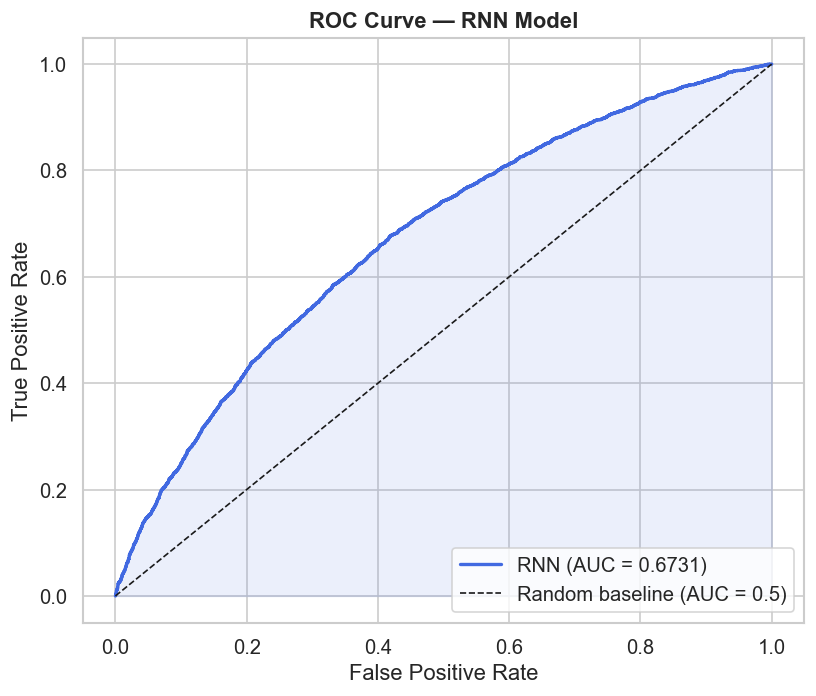

In [54]:
# ── ROC Curve ────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='royalblue', linewidth=2, label=f'RNN (AUC = {test_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='royalblue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — RNN Model', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_rnn.png', bbox_inches='tight')
plt.show()


In [55]:
# ── Prediction Analysis — Manual Inspection ──────────────────────────────

print('=== Manual Inspection of Predictions ===')
print(f'{"#":<5} {"True Label":<14} {"Pred Prob":<12} {"Pred Label":<12} {"Correct?"}')
print('-' * 55)

for i in range(min(20, len(test_labels))):
    true    = int(test_labels[i])
    prob    = test_preds[i]
    pred    = int(prob > 0.5)
    correct = '✓' if pred == true else '✗'
    print(f'{i:<5} {true:<14} {prob:<12.4f} {pred:<12} {correct}')

print()
print('Confidence on correct predictions :')
correct_mask = (test_preds_binary == 1) & (test_labels == 1)
print(f'  Mean prob when TP: {test_preds[correct_mask].mean():.4f}')
print('Confidence on wrong predictions (false positives):')
fp_mask = (test_preds_binary == 1) & (test_labels == 0)
if fp_mask.sum() > 0:
    print(f'  Mean prob when FP: {test_preds[fp_mask].mean():.4f}')


=== Manual Inspection of Predictions ===
#     True Label     Pred Prob    Pred Label   Correct?
-------------------------------------------------------
0     1              0.4264       0            ✗
1     1              0.4475       0            ✗
2     0              0.3315       0            ✓
3     1              0.6436       1            ✓
4     0              0.1615       0            ✓
5     0              0.4305       0            ✓
6     0              0.1394       0            ✓
7     0              0.4038       0            ✓
8     0              0.4300       0            ✓
9     0              0.5224       1            ✗
10    1              0.7386       1            ✓
11    1              0.1955       0            ✗
12    0              0.2937       0            ✓
13    1              0.5694       1            ✓
14    1              0.3417       0            ✗
15    0              0.3744       0            ✓
16    1              0.4136       0            ✗
17    1       

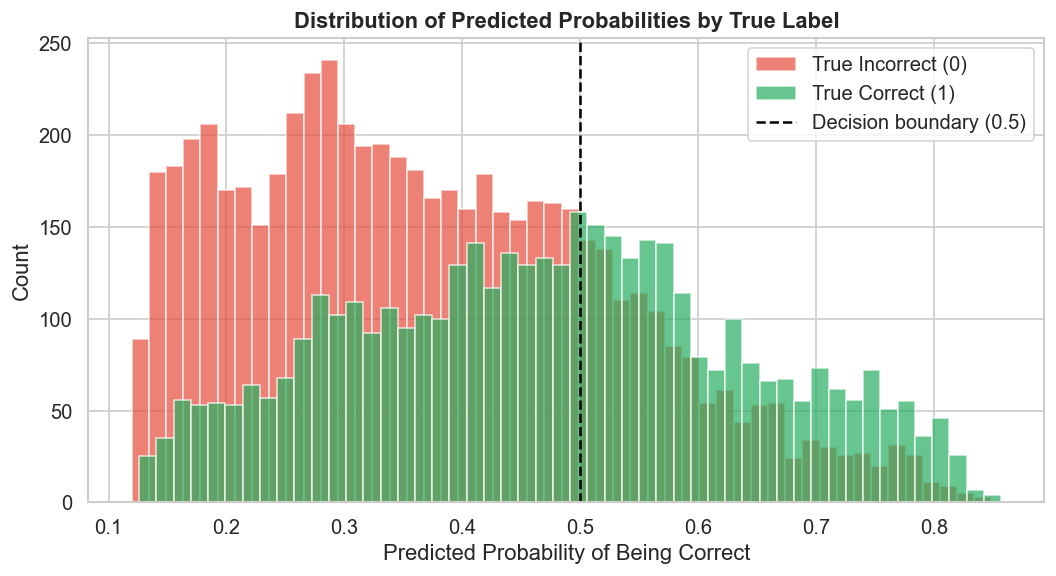

In [56]:
# ── Prediction Probability Distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(test_preds[test_labels == 0], bins=50, alpha=0.7, color='#E74C3C', label='True Incorrect (0)')
ax.hist(test_preds[test_labels == 1], bins=50, alpha=0.7, color='#27AE60', label='True Correct (1)')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
ax.set_xlabel('Predicted Probability of Being Correct')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Probabilities by True Label', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('pred_distribution_rnn.png', bbox_inches='tight')
plt.show()



---
## 9. ⭐ BONUS: LSTM Model & Comparison

```
  Forget gate:  f_t = σ(W_f · [h_{t-1}, x_t] + b_f)   ← what to erase from memory
  Input gate:   i_t = σ(W_i · [h_{t-1}, x_t] + b_i)   ← what new info to store
  Cell update:  c̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c)
  Cell state:   c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t       ← updated memory
  Output gate:  o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
  Hidden state: h_t = o_t ⊙ tanh(c_t)                  ← what to output
```



In [57]:
class KnowledgeTracingLSTM(nn.Module):
    """
    LSTM-based Knowledge Tracing model.
    Identical architecture to the RNN version but uses nn.LSTM instead of nn.RNN.
    """
    def __init__(self, n_skills, embed_dim, n_features, hidden_dim, n_layers, dropout):
        super().__init__()

        self.skill_embed = nn.Embedding(
            num_embeddings=n_skills,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        rnn_input_dim = embed_dim + (n_features - 1)

        self.lstm = nn.LSTM(
            input_size=rnn_input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        skill_idx     = x[:, :, 1].long()
        skill_embedded = self.skill_embed(skill_idx)
        other_feats   = torch.cat([x[:, :, :1], x[:, :, 2:]], dim=2)
        lstm_input    = torch.cat([skill_embedded, other_feats], dim=2)

        out, (h_n, c_n) = self.lstm(lstm_input)

        last_hidden = h_n[-1]
        last_hidden = self.dropout(last_hidden)

        logit = self.fc(last_hidden).squeeze(-1)
        return torch.sigmoid(logit)


lstm_model = KnowledgeTracingLSTM(
    n_skills=N_SKILLS,
    embed_dim=EMBED_DIM,
    n_features=N_FEATURES,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

n_params_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'LSTM trainable parameters: {n_params_lstm:,}')
print(f'RNN  trainable parameters: {n_params:,}')
print(f'LSTM has ~{n_params_lstm / n_params:.1f}x more parameters (due to 4 gates vs 1 in RNN)')


LSTM trainable parameters: 130,145
RNN  trainable parameters: 34,817
LSTM has ~3.7x more parameters (due to 4 gates vs 1 in RNN)


In [58]:
# ── Train the LSTM with the SAME pipeline ─────────────────────────────────────
lstm_criterion = nn.BCELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR)
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode='min', factor=0.5, patience=3
)

lstm_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_lstm_auc  = 0.0
best_lstm_epoch = 0

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(lstm_model, train_loader, lstm_criterion, lstm_optimizer, DEVICE)
    val_loss, val_acc, val_auc, _, _ = evaluate(lstm_model, val_loader, lstm_criterion, DEVICE)

    lstm_scheduler.step(val_loss)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['val_acc'].append(val_acc)
    lstm_history['val_auc'].append(val_auc)

    if val_auc > best_lstm_auc:
        best_lstm_auc   = val_auc
        best_lstm_epoch = epoch
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pt')

    print(f'Epoch {epoch:02d}/{N_EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  '
          f'Val Loss: {val_loss:.4f}  '
          f'Val Acc: {val_acc:.4f}  '
          f'Val AUC: {val_auc:.4f}'
          f'{"  ← best" if epoch == best_lstm_epoch else ""}')

print(f'\nBest LSTM at epoch {best_lstm_epoch} with Val AUC = {best_lstm_auc:.4f}')


Epoch 01/30  Train Loss: 0.6613  Val Loss: 0.6511  Val Acc: 0.6290  Val AUC: 0.6304  ← best
Epoch 02/30  Train Loss: 0.6509  Val Loss: 0.6452  Val Acc: 0.6355  Val AUC: 0.6457  ← best
Epoch 03/30  Train Loss: 0.6450  Val Loss: 0.6401  Val Acc: 0.6434  Val AUC: 0.6586  ← best
Epoch 04/30  Train Loss: 0.6392  Val Loss: 0.6323  Val Acc: 0.6443  Val AUC: 0.6739  ← best
Epoch 05/30  Train Loss: 0.6319  Val Loss: 0.6282  Val Acc: 0.6477  Val AUC: 0.6803  ← best
Epoch 06/30  Train Loss: 0.6265  Val Loss: 0.6267  Val Acc: 0.6489  Val AUC: 0.6837  ← best
Epoch 07/30  Train Loss: 0.6220  Val Loss: 0.6243  Val Acc: 0.6518  Val AUC: 0.6876  ← best
Epoch 08/30  Train Loss: 0.6172  Val Loss: 0.6222  Val Acc: 0.6537  Val AUC: 0.6906  ← best
Epoch 09/30  Train Loss: 0.6135  Val Loss: 0.6215  Val Acc: 0.6576  Val AUC: 0.6936  ← best
Epoch 10/30  Train Loss: 0.6076  Val Loss: 0.6193  Val Acc: 0.6580  Val AUC: 0.6972  ← best
Epoch 11/30  Train Loss: 0.6047  Val Loss: 0.6190  Val Acc: 0.6577  Val AUC: 0.6

In [59]:
# ── Evaluate LSTM on Test Set ─────────────────────────────────────────────────
lstm_model.load_state_dict(torch.load('best_lstm_model.pt', map_location=DEVICE))

lstm_test_loss, lstm_test_acc, lstm_test_auc, lstm_test_preds, _ = evaluate(
    lstm_model, test_loader, lstm_criterion, DEVICE
)

lstm_preds_binary = (lstm_test_preds > 0.5).astype(int)
lstm_precision    = precision_score(test_labels, lstm_preds_binary)
lstm_recall       = recall_score(test_labels, lstm_preds_binary)

print('=' * 55)
print('       TEST SET RESULTS — COMPARISON')
print('=' * 55)
print(f'{"Metric":<15} {"RNN":>12} {"LSTM":>12}')
print('-' * 40)
print(f'{"Loss":<15} {test_loss:>12.4f} {lstm_test_loss:>12.4f}')
print(f'{"Accuracy":<15} {test_acc:>12.4f} {lstm_test_acc:>12.4f}')
print(f'{"Precision":<15} {precision:>12.4f} {lstm_precision:>12.4f}')
print(f'{"Recall":<15} {recall:>12.4f} {lstm_recall:>12.4f}')
print(f'{"AUC":<15} {test_auc:>12.4f} {lstm_test_auc:>12.4f}')
print('=' * 55)


       TEST SET RESULTS — COMPARISON
Metric                   RNN         LSTM
----------------------------------------
Loss                  0.6356       0.6217
Accuracy              0.6434       0.6560
Precision             0.6001       0.6021
Recall                0.4440       0.5256
AUC                   0.6731       0.6979


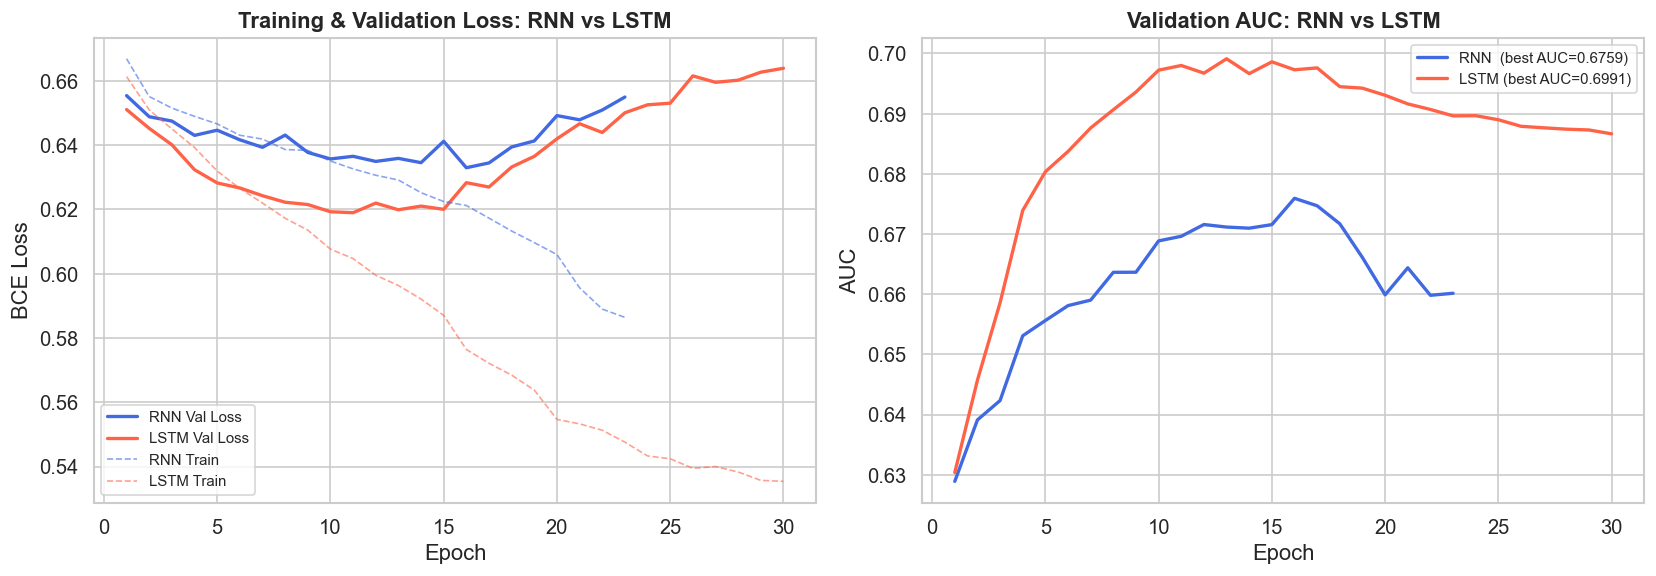

In [60]:
# ── Side-by-Side Training Curves: RNN vs LSTM ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_RNN = range(1, len(history['train_loss']) + 1)
epochs = range(1, N_EPOCHS + 1)

# Loss
axes[0].plot(epochs_RNN, history['val_loss'],      label='RNN Val Loss',  color='royalblue', linewidth=2)
axes[0].plot(epochs, lstm_history['val_loss'], label='LSTM Val Loss', color='tomato',    linewidth=2)
axes[0].plot(epochs_RNN, history['train_loss'],    label='RNN Train',     color='royalblue', linewidth=1, linestyle='--', alpha=0.6)
axes[0].plot(epochs, lstm_history['train_loss'], label='LSTM Train',  color='tomato',    linewidth=1, linestyle='--', alpha=0.6)
axes[0].set_title('Training & Validation Loss: RNN vs LSTM', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(fontsize=9)

# AUC
axes[1].plot(epochs_RNN, history['val_auc'],      label=f'RNN  (best AUC={best_val_auc:.4f})',  color='royalblue', linewidth=2)
axes[1].plot(epochs, lstm_history['val_auc'], label=f'LSTM (best AUC={best_lstm_auc:.4f})', color='tomato',    linewidth=2)
axes[1].set_title('Validation AUC: RNN vs LSTM', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparison_rnn_vs_lstm.png', bbox_inches='tight')
plt.show()


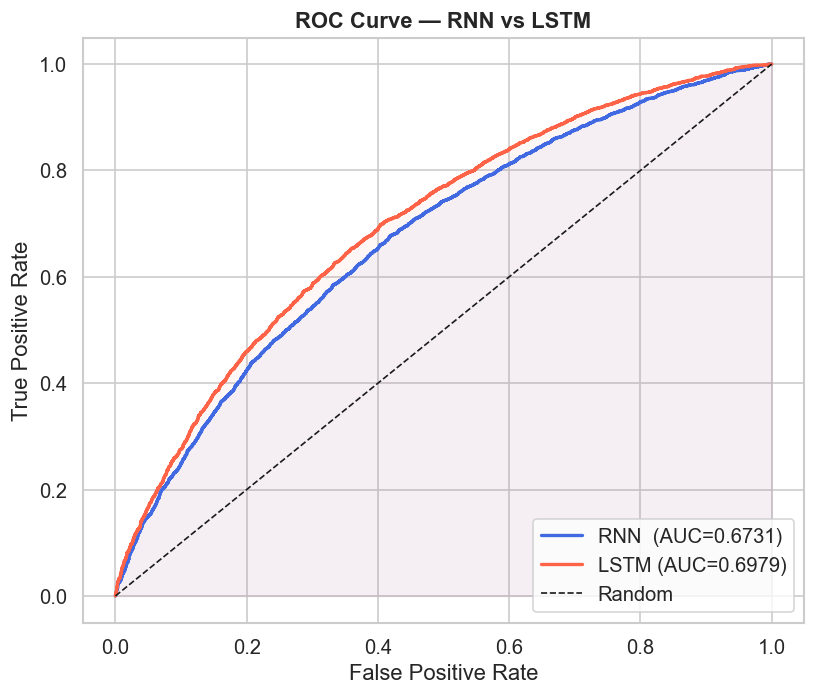

In [61]:
# ── ROC Curve Overlay: RNN vs LSTM ────────────────────────────────────────────
from sklearn.metrics import roc_curve

fpr_rnn,  tpr_rnn,  _ = roc_curve(test_labels, test_preds)
fpr_lstm, tpr_lstm, _ = roc_curve(test_labels, lstm_test_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_rnn,  tpr_rnn,  color='royalblue', linewidth=2, label=f'RNN  (AUC={test_auc:.4f})')
ax.plot(fpr_lstm, tpr_lstm, color='tomato',    linewidth=2, label=f'LSTM (AUC={lstm_test_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.fill_between(fpr_rnn,  tpr_rnn,  alpha=0.05, color='royalblue')
ax.fill_between(fpr_lstm, tpr_lstm, alpha=0.05, color='tomato')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — RNN vs LSTM', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_comparison.png', bbox_inches='tight')
plt.show()



### RNN vs LSTM Discussion (Bonus Section)
The hyperparameter tuning results show that the LSTM baseline achieved a higher validation AUC than the vanilla RNN baseline. Both models were trained with the same configuration: sequence length of 10, hidden size of 128, 2 recurrent layers, dropout of 0.3, and learning rate of 0.001. Therefore, the comparison mainly reflects the effect of the recurrent architecture.

The vanilla RNN obtained a validation AUC of 0.6724, while the LSTM achieved 0.6980. This corresponds to an absolute improvement of approximately 0.0256 AUC points. The improvement suggests that the LSTM is better able to capture temporal dependencies in the student interaction sequence. In a Knowledge Tracing setting, this means that the gated memory mechanism of LSTM can preserve useful information about previous student responses more effectively than a standard RNN.

However, the improvement is moderate rather than large. This may indicate that the dataset contains some long-range dependencies, but a considerable part of the predictive signal may still come from short-range interactions. In other words, the recent student history may already provide much of the information needed for prediction, allowing the vanilla RNN to remain competitive.

The main trade-off is computational cost. For the same hidden dimension, an LSTM typically has around four times more recurrent parameters than a vanilla RNN because it uses separate transformations for the input gate, forget gate, output gate, and candidate memory. Therefore, the LSTM provides better predictive performance in this experiment, but at the cost of higher model complexity and training time.


## Question 3: Explain mathematically the vanishing gradient problem in RNNs. Then, analyze how changing the sequence length, or lookback window size, impacts the severity of this phenomenon.

In a standard recurrent neural network, the hidden state at time step t is computed as:

h_t = φ(W_x x_t + W_h h_{t-1} + b)      
where x_t is the input, h_t is the hidden state, W_x is the input-to-hidden weight matrix, W_h is the recurrent weight matrix, and φ is a nonlinear activation function such as tanh.

During training, the network is optimized using Backpropagation Through Time, or BPTT. The loss at a later time step depends not only on the current hidden state, but also on previous hidden states. Therefore, to update the parameters related to earlier time steps, gradients must be propagated backward through many recurrent transitions.

Mathematically, the gradient of a loss L_t at time step t with respect to a previous hidden state h_k, where k < t, can be written using the chain rule:

∂L_t / ∂h_k = ∂L_t / ∂h_t · ∂h_t / ∂h_k     
The term ∂h_t / ∂h_k expands into a product of Jacobian matrices:

∂h_t / ∂h_k = Π_{i=k+1}^{t} ∂h_i / ∂h_{i-1}     
For a simple RNN:

h_i = φ(W_x x_i + W_h h_{i-1} + b)      
so:

∂h_i / ∂h_{i-1} = diag(φ'(a_i)) W_h     
where:

a_i = W_x x_i + W_h h_{i-1} + b     
Therefore:

∂L_t / ∂h_k =
∂L_t / ∂h_t · Π_{i=k+1}^{t} [diag(φ'(a_i)) W_h]     
This product is the main source of the vanishing gradient problem. If the norm of each Jacobian matrix is smaller than one, then repeated multiplication causes the gradient norm to shrink exponentially as the distance between t and k increases.

Using a norm bound:

||∂L_t / ∂h_k|| ≤ ||∂L_t / ∂h_t|| · Π_{i=k+1}^{t} ||diag(φ'(a_i)) W_h||     
If we assume:

||diag(φ'(a_i)) W_h|| ≤ α       
with:

α < 1       
then:


||∂L_t / ∂h_k|| ≤ ||∂L_t / ∂h_t|| · α^(t-k)     
Since α^(t-k) decreases exponentially when t-k increases, the gradient becomes extremely small for earlier time steps. As a result, the model cannot effectively learn long-term dependencies, because the contribution of old inputs to the current loss becomes almost negligible during training.

For example, if α = 0.5 and the dependency spans 20 time steps, then:

α^20 = 0.5^20 ≈ 0.00000095
This means the gradient reaching the earlier time step is almost zero.

The activation function also contributes to this issue. For example, the derivative of tanh satisfies:

0 < φ'(x) ≤ 1
and when tanh saturates near -1 or 1, its derivative becomes close to zero. This makes the product of Jacobians even smaller.

The sequence length, or lookback window size, directly affects the severity of the vanishing gradient problem. A longer lookback window means the gradient must be propagated through more recurrent steps. Since the gradient involves repeated multiplication by recurrent Jacobians, increasing the sequence length increases the exponent in the term:

α^(t-k)
Therefore, longer sequences make vanishing gradients more severe. The model becomes less capable of learning dependencies from distant past events because the gradient signal reaching those earlier steps becomes very weak.

In contrast, using a shorter lookback window reduces the number of recurrent multiplications. This makes the gradient less likely to vanish and can make training more stable. However, a shorter window also limits the amount of historical information available to the model. If important dependencies occur outside the selected window, the model will not be able to use them.

Thus, there is a trade-off:

Longer lookback window:
- Provides more historical context.
- Can capture long-term dependencies.
- Increases the risk of vanishing gradients.
- Makes training harder and less stable.

Shorter lookback window:
- Reduces the severity of vanishing gradients.
- Makes optimization easier.
- Requires less computation.
- May lose important long-term information.
In Knowledge Tracing tasks, this trade-off is especially important. A longer sequence may contain useful information about a student’s previous mastery, misconceptions, or forgetting patterns. However, if a simple RNN is used, increasing the lookback window can make it difficult for the model to learn from old interactions because of vanishing gradients. This is one reason why architectures such as LSTM are often preferred: they introduce gated memory mechanisms and a cell state that help preserve information and allow gradients to flow more effectively over longer sequences.